# Notebook 02: Curvas de Tasas Reales — LECER y CER

Visualización de la curva TIR vs Duration a lo largo del tiempo, con granularidad configurable.

**Objetivo:** Entender cómo evolucionó la estructura de tasas reales e identificar qué períodos son representativos del régimen actual (útiles para entrenamiento del modelo).

**Contenido:**
1. Curva LECER: promedio mensual de TIR vs Duration
2. Curva CER: promedio trimestral de TIR vs Duration

**Conclusiones del análisis:**
- Las curvas CER **anteriores a 2025-Q2** reflejan un régimen de desinflación acelerada muy distinto al actual — no representativas para entrenamiento, pero valiosas si se repite ese contexto.
- Los períodos **anteriores a la incorporación de todos los bonos actuales** no tienen cobertura completa del tramo corto, lo que sesga el ajuste Nelson-Siegel (β1 mal identificado).
- El **rango útil para modelado** arranca en 2025-Q2 aproximadamente.

In [18]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dotenv import load_dotenv
load_dotenv(os.path.join(project_root, '.env'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sqlalchemy import text
from src.db.session import SessionLocal

print('Setup OK')

Setup OK


In [19]:
# ─────────────────────────────────────────
#  PARÁMETROS — modificar acá
# ─────────────────────────────────────────
FECHA_INICIO = '2020-01-01'   # dejar temprano para mostrar desde el primer dato disponible
FECHA_FIN    = '2026-03-04'

In [20]:
# Carga de datos desde PostgreSQL
with SessionLocal() as db:
    df = pd.read_sql(
        text("""
            SELECT
                p.ticker,
                p.fecha,
                m.tir,
                m.duration_modificada,
                b.grupo
            FROM precios_raw p
            JOIN metricas_diarias m ON m.precio_id = p.id
            JOIN bonos b ON b.ticker = p.ticker
            WHERE p.fecha BETWEEN :inicio AND :fin
            ORDER BY p.fecha, m.duration_modificada
        """),
        db.bind,
        params={"inicio": FECHA_INICIO, "fin": FECHA_FIN},
        parse_dates=['fecha']
    )

df['tir_pct'] = df['tir'].astype(float) * 100
df['duration_modificada'] = df['duration_modificada'].astype(float)
df = df.dropna(subset=['tir_pct', 'duration_modificada'])

fechas = sorted(df['fecha'].unique())
print(f"Registros: {len(df):,}  |  Días: {len(fechas)}  |  {fechas[0].date()} → {fechas[-1].date()}")

Registros: 11,806  |  Días: 1119  |  2021-06-16 → 2026-03-04


/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_72352/1141684932.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


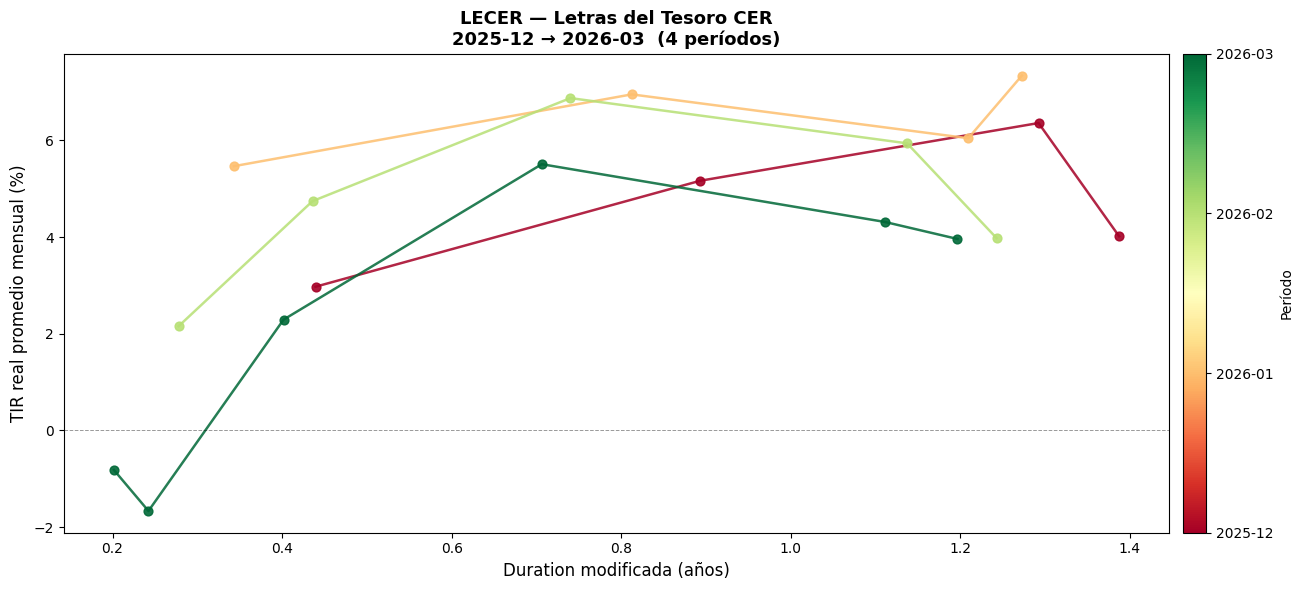

/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_72352/1141684932.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


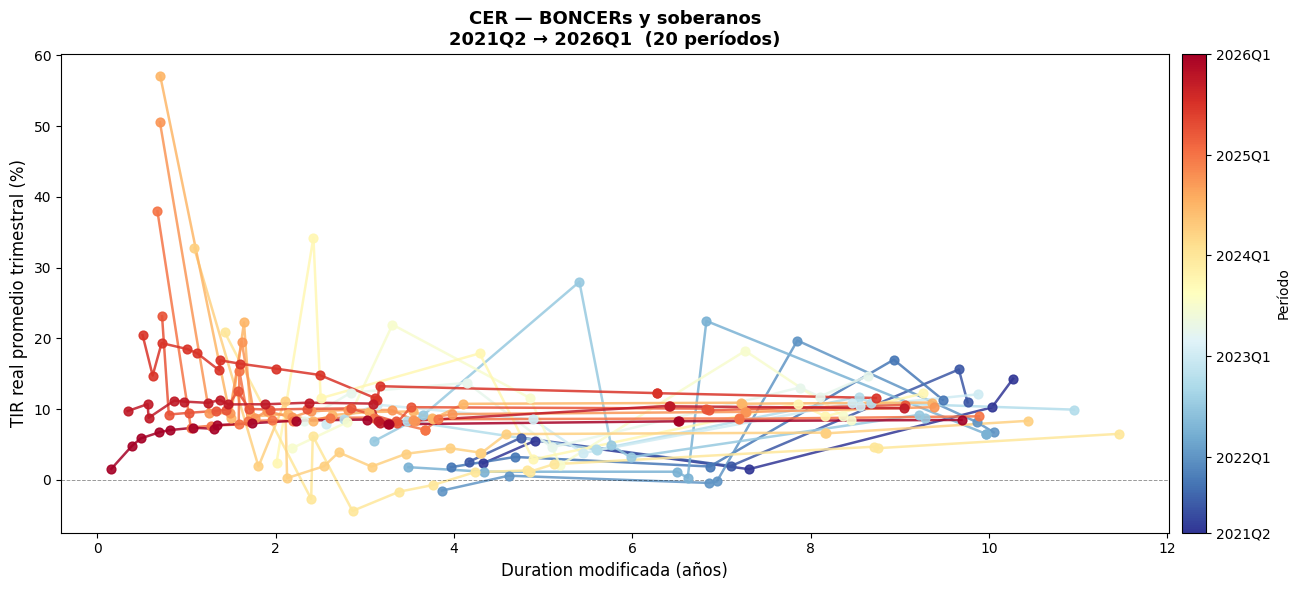

In [21]:
def plot_curvas_mensual(df_panel, titulo, cmap_name='RdYlGn', min_puntos=2, freq='M'):
    """
    Una línea por período: TIR promedio del período de cada bono vs su duration promedio.
    freq='M' → mensual | freq='Q' → trimestral
    Color: rojo=período más antiguo, verde=más reciente.
    """
    df_panel = df_panel.copy()
    df_panel['periodo'] = df_panel['fecha'].dt.to_period(freq)

    mensual = (
        df_panel.groupby(['periodo', 'ticker'])[['tir_pct', 'duration_modificada']]
        .mean()
        .reset_index()
    )

    periodos = sorted(mensual['periodo'].unique())
    n = len(periodos)
    if n == 0:
        print(f"Sin datos para {titulo}")
        return

    cmap = cm.get_cmap(cmap_name, n)

    fig, ax = plt.subplots(figsize=(14, 6))

    for idx, periodo in enumerate(periodos):
        corte = mensual[mensual['periodo'] == periodo].sort_values('duration_modificada')
        corte = corte.dropna(subset=['tir_pct', 'duration_modificada'])
        if len(corte) < min_puntos:
            continue
        color = cmap(idx / max(n - 1, 1))
        ax.plot(
            corte['duration_modificada'], corte['tir_pct'],
            color=color, linewidth=1.8, alpha=0.85
        )
        ax.scatter(
            corte['duration_modificada'], corte['tir_pct'],
            color=color, s=40, zorder=4, alpha=0.9
        )

    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_xlabel('Duration modificada (años)', fontsize=12)
    label_y = 'TIR real promedio trimestral (%)' if freq == 'Q' else 'TIR real promedio mensual (%)'
    ax.set_ylabel(label_y, fontsize=12)
    ax.set_title(
        f'{titulo}\n{periodos[0]} → {periodos[-1]}  ({n} períodos)',
        fontsize=13, fontweight='bold'
    )

    norm = mcolors.Normalize(vmin=0, vmax=max(n - 1, 1))
    sm = cm.ScalarMappable(cmap=cmap_name, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    tick_indices = np.linspace(0, n - 1, min(6, n), dtype=int)
    cbar.set_ticks(tick_indices)
    cbar.set_ticklabels([str(periodos[i]) for i in tick_indices])
    cbar.set_label('Período', fontsize=10)

    plt.tight_layout()
    plt.show()


# ── LECER — mensual ───────────────────────────────────────────
df_lecer = df[df['grupo'] == 'lecer']
plot_curvas_mensual(df_lecer, 'LECER — Letras del Tesoro CER', cmap_name='RdYlGn', freq='M')

# ── CER — trimestral ──────────────────────────────────────────
df_cer = df[df['grupo'] == 'cer']
plot_curvas_mensual(df_cer, 'CER — BONCERs y soberanos', cmap_name='RdYlBu_r', freq='Q')

# Comentarios

Lo unico que vale la pena remarcar para estos graficos se da en el de bonos CER.

1: 
    Los periodos antiguos no funcionaran correctamente para el estudio de estos ya que al no estar todos los bonos actuales la curva generada no reflejara la situacion actual.

2: 
    Las curvas anteriores al 2025Q2 son muy diferentes a las actuales, por lo que, dada la situacion actual no serviran para un entrenamiento correcto. 
    No significa que seran descartadas, en el caso de darse una situacion parecida a la que se vivia en su momento estas seran realmente utiles. Para contexto, al ver el notebook 1 se muestra que precio a 2025Q2 se estaba transcurriendo un momento de desinflacion acelerada y, mas cerca de la fecha, una inflacion considerablemente mayor a la actual.

A continuacion se mostrara nuevamente una curva de los bonos CER para intentar hacer un ajuste un poco mas fino sobre las fechas a consultar.

/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_72352/1389525203.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


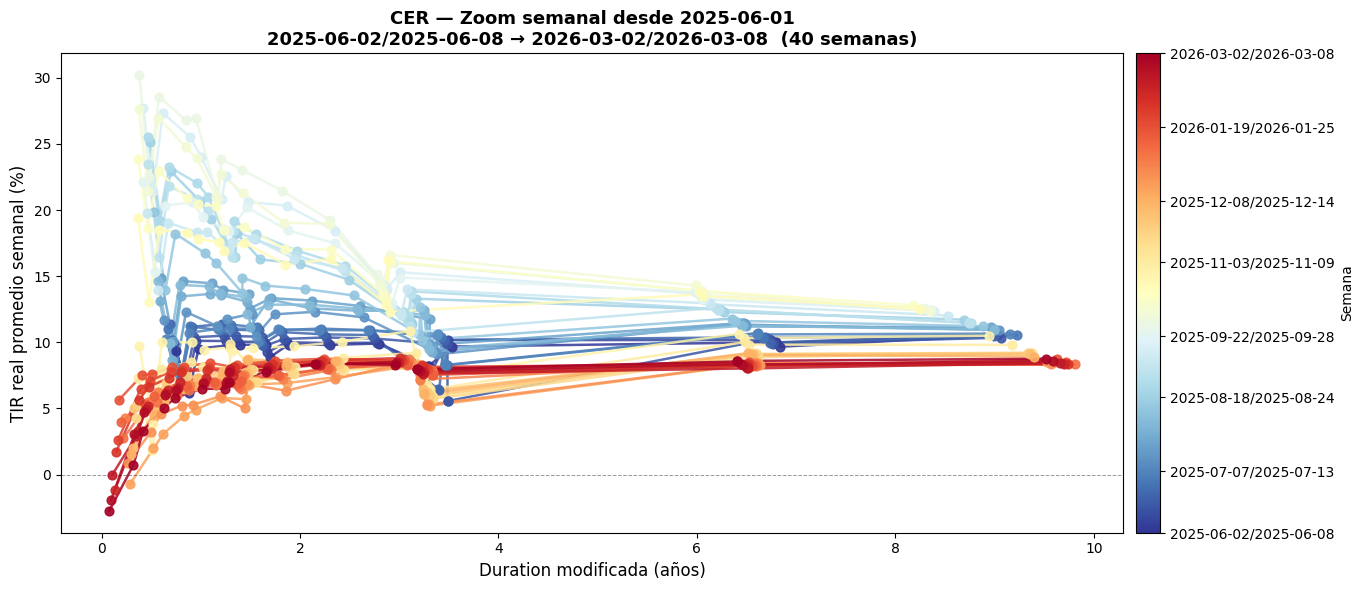

In [22]:

# ── CER — semanal desde 2025-06 ───────────────────────────────
# Promedio semanal de TIR vs Duration para afinar qué semanas
# son representativas del régimen actual.

FECHA_ZOOM_INICIO = '2025-06-01'

df_cer_zoom = df[
    (df['grupo'] == 'cer') &
    (df['fecha'] >= FECHA_ZOOM_INICIO)
].copy()

df_cer_zoom['periodo'] = df_cer_zoom['fecha'].dt.to_period('W')

semanal = (
    df_cer_zoom.groupby(['periodo', 'ticker'])[['tir_pct', 'duration_modificada']]
    .mean()
    .reset_index()
)

periodos = sorted(semanal['periodo'].unique())
n = len(periodos)

cmap_name = 'RdYlBu_r'
cmap = cm.get_cmap(cmap_name, n)

fig, ax = plt.subplots(figsize=(14, 6))

for idx, periodo in enumerate(periodos):
    corte = semanal[semanal['periodo'] == periodo].sort_values('duration_modificada')
    corte = corte.dropna(subset=['tir_pct', 'duration_modificada'])
    if len(corte) < 2:
        continue
    color = cmap(idx / max(n - 1, 1))
    ax.plot(
        corte['duration_modificada'], corte['tir_pct'],
        color=color, linewidth=1.8, alpha=0.85
    )
    ax.scatter(
        corte['duration_modificada'], corte['tir_pct'],
        color=color, s=40, zorder=4, alpha=0.9
    )

ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax.set_xlabel('Duration modificada (años)', fontsize=12)
ax.set_ylabel('TIR real promedio semanal (%)', fontsize=12)
ax.set_title(
    f'CER — Zoom semanal desde {FECHA_ZOOM_INICIO}\n{periodos[0]} → {periodos[-1]}  ({n} semanas)',
    fontsize=13, fontweight='bold'
)

norm = mcolors.Normalize(vmin=0, vmax=max(n - 1, 1))
sm = cm.ScalarMappable(cmap=cmap_name, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
tick_indices = np.linspace(0, n - 1, min(8, n), dtype=int)
cbar.set_ticks(tick_indices)
cbar.set_ticklabels([str(periodos[i]) for i in tick_indices])
cbar.set_label('Semana', fontsize=10)

plt.tight_layout()
plt.show()


# Comentarios

Dado este grafico con una muestra mas fina de lo que sucede, a partir de la situacion actual inflacionaria se evaluara de aqui en adelante los bonos CER con fechas mayores a 2025-12-08.

/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_72352/1955041509.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_lecer = cm.get_cmap(cmap_name_lecer, n_lecer)


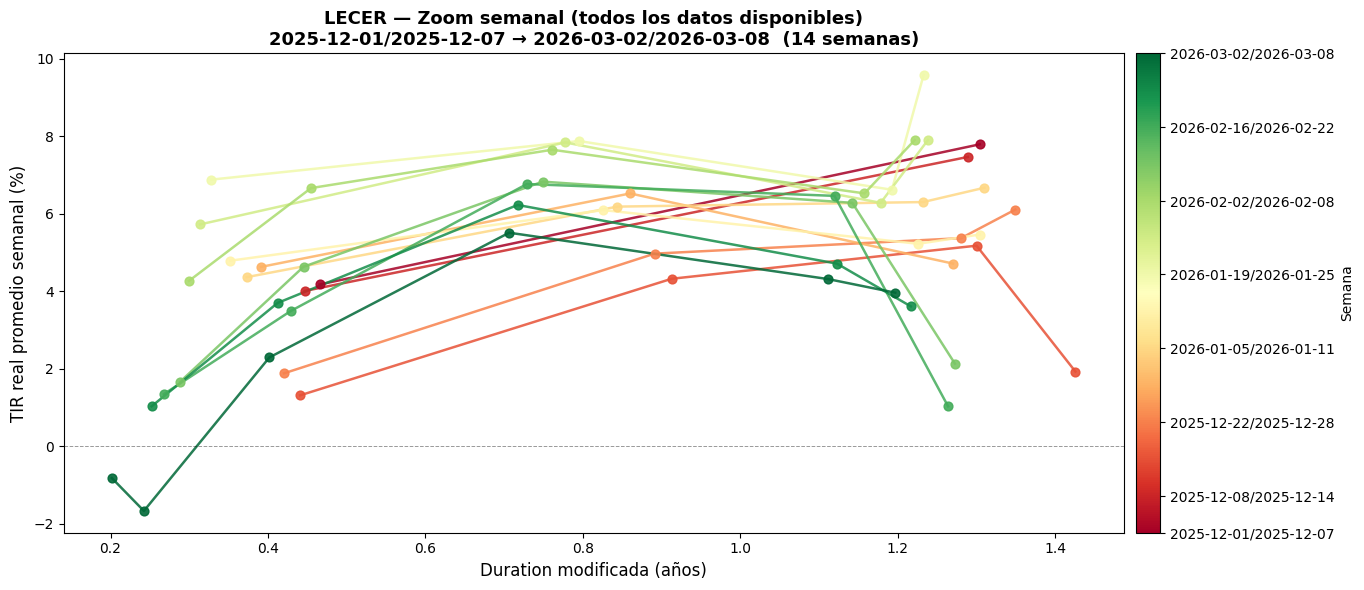

In [23]:

# ── LECER — semanal (todos los datos disponibles) ─────────────
# Misma granularidad que el gráfico CER anterior.
# Los LECER existen desde fines de 2025, por lo que el rango es corto
# pero cubre la totalidad del historial disponible.

df_lecer_zoom = df[df['grupo'] == 'lecer'].copy()

df_lecer_zoom['periodo'] = df_lecer_zoom['fecha'].dt.to_period('W')

semanal_lecer = (
    df_lecer_zoom.groupby(['periodo', 'ticker'])[['tir_pct', 'duration_modificada']]
    .mean()
    .reset_index()
)

periodos_lecer = sorted(semanal_lecer['periodo'].unique())
n_lecer = len(periodos_lecer)

cmap_name_lecer = 'RdYlGn'
cmap_lecer = cm.get_cmap(cmap_name_lecer, n_lecer)

fig, ax = plt.subplots(figsize=(14, 6))

for idx, periodo in enumerate(periodos_lecer):
    corte = semanal_lecer[semanal_lecer['periodo'] == periodo].sort_values('duration_modificada')
    corte = corte.dropna(subset=['tir_pct', 'duration_modificada'])
    if len(corte) < 2:
        continue
    color = cmap_lecer(idx / max(n_lecer - 1, 1))
    ax.plot(
        corte['duration_modificada'], corte['tir_pct'],
        color=color, linewidth=1.8, alpha=0.85
    )
    ax.scatter(
        corte['duration_modificada'], corte['tir_pct'],
        color=color, s=40, zorder=4, alpha=0.9
    )

ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax.set_xlabel('Duration modificada (años)', fontsize=12)
ax.set_ylabel('TIR real promedio semanal (%)', fontsize=12)
ax.set_title(
    f'LECER — Zoom semanal (todos los datos disponibles)\n'
    f'{periodos_lecer[0]} → {periodos_lecer[-1]}  ({n_lecer} semanas)',
    fontsize=13, fontweight='bold'
)

norm = mcolors.Normalize(vmin=0, vmax=max(n_lecer - 1, 1))
sm = cm.ScalarMappable(cmap=cmap_name_lecer, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
tick_indices = np.linspace(0, n_lecer - 1, min(8, n_lecer), dtype=int)
cbar.set_ticks(tick_indices)
cbar.set_ticklabels([str(periodos_lecer[i]) for i in tick_indices])
cbar.set_label('Semana', fontsize=10)

plt.tight_layout()
plt.show()


# Comentarios

A diferencia de los CER no parece haber una regla general para estas curvas, esto puede deberse a que, al ser de tan corta duracion, se ve el ruido con mayor detalle. Pero el problema principal parece darse, viendolo en detalle, porque en muchos casos hay pocos nodos en las curvas analizadas. De esta manera, restringire las fechas de los LECER para que muestren desde que hay por lo menos 5 bonos vigentes para su analisis, esto reflejara aproximadamente desde el 2 de febrero de 2026. Esto no nos da muchos dias con los que trabajar pero con mas datos se cree que el rendimiento empeorara. 

En versiones posteriores de esto se intentara evaluar bonos que no estan vigentes actualmente para poder modelar una mayor cantidad de curvas con el objetivo de intentar conseguir una mejor generalizacion.